# CDT Morris CRISPRi: Attention Map Analysis (Stage 1.5)

## Overview
- **Goal**: Extract and visualize CDT Attention Maps to discover biological patterns
- **Model**: CDT-II Stage 1.5 (DNA + RNA, 2,361 genes including GFI1B)
- **Data**: Morris STINGseq TSS + SNP perturbations (cell-level)

## Stage 1.5 Key Change
- **GFI1B is now at index 2360 in RNA Self-Attention [2361×2361]**
- Direct analysis of GFI1B's attention patterns (query/key) is now possible
- Stage 1 could only do indirect analysis (GFI1B was not in the 2,360 gene list)

## Contents
1. Setup & Data Loading
2. Model Definition (with Attention Extraction)
3. Attention Extraction Functions
4. GFI1B Case Study: RNA Self-Attention
5. CD52 Case Study: Drug Target Analysis
6. DNA->RNA Cross-Attention Analysis
7. DNA Self-Attention Analysis
8. VCE Pooling Attention
9. Cell-to-Cell Attention Variation
10. Per-Head Specialization Summary
11. Save & Export

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.9.0+cu126
CUDA: True
GPU: Tesla T4


In [ ]:
!pip install h5py tqdm scipy seaborn -q

import os
import h5py
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Optional, Dict, List, Tuple

class NumpyEncoder(json.JSONEncoder):
    """JSON encoder that handles numpy types."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        return super().default(obj)

print("Imports done!")

Imports done!


## 2. Paths & Data Loading

In [ ]:
# Paths (Stage 1.5)
DRIVE_BASE = Path("/content/drive/MyDrive/cdt_data")
MODEL_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5")
OUTPUT_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

TSS_EFFECTS_PATH = DRIVE_BASE / "morris_celllevel_effects_2361.h5"
SNP_EFFECTS_PATH = DRIVE_BASE / "morris_snp_celllevel_effects_2361.h5"
TSS_ENFORMER_PATH = DRIVE_BASE / "morris_28genes_enformer.h5"
SNP_ENFORMER_PATH = DRIVE_BASE / "morris_snp_enformer.h5"
GENE_LIST_PATH = DRIVE_BASE / "k562_gene_embeddings_aligned.h5"
MODEL_PATH = MODEL_BASE / "cdt_morris_celllevel_best.pt"

print("Checking files...")
for name, path in [
    ("TSS effects (2361)", TSS_EFFECTS_PATH),
    ("TSS Enformer", TSS_ENFORMER_PATH),
    ("Gene list", GENE_LIST_PATH),
    ("Model (Stage 1.5)", MODEL_PATH),
]:
    status = "OK" if path.exists() else "NOT FOUND"
    print(f"  [{status}] {name}")

Checking files...
  [OK] TSS effects (2361)
  [OK] TSS Enformer
  [OK] Gene list
  [OK] Model (Stage 1.5)


In [ ]:
# Load data (Stage 1.5: 2361 genes)
print("Loading CDT gene list...")

# Load base 2360 genes from RNA embeddings, then append GFI1B
with h5py.File(GENE_LIST_PATH, 'r') as f:
    cdt_genes = [g.decode() if isinstance(g, bytes) else g for g in f['gene_names'][:]]
if 'GFI1B' not in cdt_genes:
    cdt_genes.append('GFI1B')
    print("  GFI1B appended to gene list.")
N_GENES = len(cdt_genes)
gene_to_idx = {g: i for i, g in enumerate(cdt_genes)}
assert N_GENES == 2361, f"Expected 2361 genes, got {N_GENES}"
print(f"  CDT genes: {N_GENES}")
print(f"  GFI1B index: {gene_to_idx['GFI1B']}")

print("Loading TSS cell-level effects...")
with h5py.File(TSS_EFFECTS_PATH, 'r') as f:
    tss_log2fc = f['log2fc'][:]
    tss_cell_expr = f['cell_expr'][:]
    tss_target_gene_idx = f['target_gene_idx'][:]
    tss_target_gene_names = [g.decode() if isinstance(g, bytes) else g
                             for g in f['target_gene_names'][:]]
    tss_val_genes = [g.decode() if isinstance(g, bytes) else g
                     for g in f['val_genes'][:]]
    tss_train_genes = [g.decode() if isinstance(g, bytes) else g
                       for g in f['train_genes'][:]]
print(f"  Cells: {tss_log2fc.shape[0]}, Genes: {tss_log2fc.shape[1]}")
print(f"  Val genes: {tss_val_genes}")

print("Loading Enformer embeddings...")
with h5py.File(TSS_ENFORMER_PATH, 'r') as f:
    tss_enformer_emb = f['embeddings'][:]
    tss_enformer_genes = [g.decode() if isinstance(g, bytes) else g
                          for g in f['gene_names'][:]]
tss_gene_to_enformer = {gene: i for i, gene in enumerate(tss_enformer_genes)}
print(f"  TSS Enformer: {tss_enformer_emb.shape}")

if SNP_ENFORMER_PATH.exists():
    with h5py.File(SNP_ENFORMER_PATH, 'r') as f:
        snp_enformer_emb = f['embeddings'][:]
        snp_enformer_ids = f['snp_ids'][:]
    print(f"  SNP Enformer: {snp_enformer_emb.shape}")
    HAS_SNP_ENF = True
else:
    HAS_SNP_ENF = False



# Build val cell masks per gene
val_cells_by_gene = {}
for gene in tss_val_genes:
    gene_idx_in_target = tss_target_gene_names.index(gene)
    mask = tss_target_gene_idx == gene_idx_in_target
    val_cells_by_gene[gene] = np.where(mask)[0]

print(f"\nVal genes cell counts:")
for gene, cells in val_cells_by_gene.items():
    print(f"  {gene}: {len(cells)} cells")

print("\nAll data loaded!")

Loading CDT gene list...
  GFI1B appended to gene list.
  CDT genes: 2361
  GFI1B index: 2360
Loading TSS cell-level effects...
  Cells: 8250, Genes: 2361
  Val genes: ['CD44', 'CD52', 'GFI1B', 'TFRC', 'TNFSF9']
Loading Enformer embeddings...
  TSS Enformer: (28, 896, 3072)
  SNP Enformer: (493, 896, 3072)

Val genes cell counts:
  CD44: 233 cells
  CD52: 131 cells
  GFI1B: 477 cells
  TFRC: 847 cells
  TNFSF9: 349 cells

All data loaded!


## 3. Model Definition (with Attention Extraction)

In [ ]:
@dataclass
class CDTCRISPRiConfig:
    dna_dim: int = 3072
    dna_seq_len: int = 896
    n_genes: int = 2361  # Stage 1.5: 2360 + GFI1B
    hidden_dim: int = 512
    nhead: int = 8
    dropout: float = 0.3
    dna_self_attn_layers: int = 2
    rna_self_attn_layers: int = 1


class RawExpressionEncoder(nn.Module):
    def __init__(self, n_genes, hidden_dim, dropout=0.1):
        super().__init__()
        self.n_genes = n_genes
        self.hidden_dim = hidden_dim
        self.gene_embedding = nn.Embedding(n_genes, hidden_dim)
        self.expr_projector = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout)
        )
        self.combine = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LayerNorm(hidden_dim), nn.Dropout(dropout)
        )

    def forward(self, expression):
        batch_size = expression.size(0)
        device = expression.device
        gene_ids = torch.arange(self.n_genes, device=device)
        gene_emb = self.gene_embedding(gene_ids).unsqueeze(0).expand(batch_size, -1, -1)
        expr_emb = self.expr_projector(expression.unsqueeze(-1))
        combined = torch.cat([gene_emb, expr_emb], dim=-1)
        return self.combine(combined)


class SequenceProjector(nn.Module):
    def __init__(self, input_dim, output_dim, dropout=0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.norm(self.linear(x)))

print("Base modules defined!")

Base modules defined!


In [ ]:
# Attention blocks with explicit weight extraction

class SelfAttentionBlockWithWeights(nn.Module):
    def __init__(self, d_model, nhead=8, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        batch_size, seq_len, _ = x.shape
        Q = self.q_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        if return_attention:
            scale = self.head_dim ** -0.5
            attn_weights = torch.matmul(Q, K.transpose(-2, -1)) * scale
            attn_weights = F.softmax(attn_weights, dim=-1)
            attn_out = torch.matmul(attn_weights, V)
        else:
            attn_out = F.scaled_dot_product_attention(Q, K, V,
                dropout_p=self.dropout_p if self.training else 0.0)
            attn_weights = None
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        attn_out = self.out_proj(attn_out)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights


class CrossAttentionBlockWithWeights(nn.Module):
    def __init__(self, d_model, nhead=8, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key_value, return_attention=False):
        batch_size, query_len, _ = query.shape
        key_len = key_value.shape[1]
        Q = self.q_proj(query).view(batch_size, query_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        if return_attention:
            scale = self.head_dim ** -0.5
            attn_weights = torch.matmul(Q, K.transpose(-2, -1)) * scale
            attn_weights = F.softmax(attn_weights, dim=-1)
            attn_out = torch.matmul(attn_weights, V)
        else:
            attn_out = F.scaled_dot_product_attention(Q, K, V,
                dropout_p=self.dropout_p if self.training else 0.0)
            attn_weights = None
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, query_len, self.d_model)
        attn_out = self.out_proj(attn_out)
        x = self.norm1(query + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights


class VCEWithWeights(nn.Module):
    """VCE (DNA + RNA) with attention weight extraction"""
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = 4
        self.head_dim = d_model // self.nhead
        self.dna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.rna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.dna_q_proj = nn.Linear(d_model, d_model)
        self.dna_k_proj = nn.Linear(d_model, d_model)
        self.dna_v_proj = nn.Linear(d_model, d_model)
        self.dna_out_proj = nn.Linear(d_model, d_model)
        self.rna_q_proj = nn.Linear(d_model, d_model)
        self.rna_k_proj = nn.Linear(d_model, d_model)
        self.rna_v_proj = nn.Linear(d_model, d_model)
        self.rna_out_proj = nn.Linear(d_model, d_model)
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), nn.LayerNorm(d_model)
        )

    def _attention_pool(self, query, key_value, q_proj, k_proj, v_proj, out_proj,
                        return_attention=False):
        batch_size = key_value.size(0)
        seq_len = key_value.size(1)
        query = query.expand(batch_size, -1, -1)
        Q = q_proj(query).view(batch_size, 1, self.nhead, self.head_dim).transpose(1, 2)
        K = k_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = v_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        if return_attention:
            scale = self.head_dim ** -0.5
            attn_weights = torch.matmul(Q, K.transpose(-2, -1)) * scale
            attn_weights = F.softmax(attn_weights, dim=-1)
            attn_out = torch.matmul(attn_weights, V)
        else:
            attn_out = F.scaled_dot_product_attention(Q, K, V)
            attn_weights = None
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, 1, self.d_model)
        output = out_proj(attn_out).squeeze(1)
        return output, attn_weights

    def forward(self, dna_encoded, rna_encoded, return_attention=False):
        dna_pooled, dna_attn = self._attention_pool(
            self.dna_query, dna_encoded,
            self.dna_q_proj, self.dna_k_proj, self.dna_v_proj, self.dna_out_proj,
            return_attention
        )
        rna_pooled, rna_attn = self._attention_pool(
            self.rna_query, rna_encoded,
            self.rna_q_proj, self.rna_k_proj, self.rna_v_proj, self.rna_out_proj,
            return_attention
        )
        concat = torch.cat([dna_pooled, rna_pooled], dim=-1)
        output = self.fusion(concat)
        if return_attention:
            return output, {'dna': dna_attn, 'rna': rna_attn}
        return output

print("Attention blocks with weights defined!")

Attention blocks with weights defined!


In [ ]:
class CDTCRISPRiModelWithAttention(nn.Module):
    """CDT CRISPRi Model with attention extraction"""
    def __init__(self, config=None):
        super().__init__()
        if config is None:
            config = CDTCRISPRiConfig()
        self.config = config
        self.dna_projector = SequenceProjector(config.dna_dim, config.hidden_dim, config.dropout)
        self.dna_self_attn_layers = nn.ModuleList([
            SelfAttentionBlockWithWeights(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.dna_self_attn_layers)
        ])
        self.rna_encoder = RawExpressionEncoder(config.n_genes, config.hidden_dim, config.dropout)
        self.rna_self_attn_layers = nn.ModuleList([
            SelfAttentionBlockWithWeights(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.rna_self_attn_layers)
        ])
        self.dna_to_rna = CrossAttentionBlockWithWeights(config.hidden_dim, config.nhead, config.dropout)
        self.vce = VCEWithWeights(config.hidden_dim, config.dropout)
        self.task_layer = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim), nn.GELU(), nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.n_genes)
        )

    def forward(self, dna_emb, rna_expr, return_attention=False):
        attention_maps = {}
        dna = self.dna_projector(dna_emb)
        rna = self.rna_encoder(rna_expr)

        # DNA Self-Attention
        dna_self_attns = []
        for layer in self.dna_self_attn_layers:
            dna, attn = layer(dna, return_attention=return_attention)
            if return_attention:
                dna_self_attns.append(attn)
        if return_attention:
            attention_maps['dna_self'] = dna_self_attns

        # RNA Self-Attention
        rna_self_attns = []
        for layer in self.rna_self_attn_layers:
            rna, attn = layer(rna, return_attention=return_attention)
            if return_attention:
                rna_self_attns.append(attn)
        if return_attention:
            attention_maps['rna_self'] = rna_self_attns

        # Cross-Attention: DNA -> RNA
        rna, cross_attn = self.dna_to_rna(query=rna, key_value=dna, return_attention=return_attention)
        if return_attention:
            attention_maps['cross_attn'] = cross_attn

        # VCE
        if return_attention:
            cell_embedding, vce_attn = self.vce(dna, rna, return_attention=True)
            attention_maps['vce'] = vce_attn
        else:
            cell_embedding = self.vce(dna, rna)

        effect = self.task_layer(cell_embedding)
        if return_attention:
            return effect, attention_maps
        return effect

print("CDTCRISPRiModelWithAttention defined!")

CDTCRISPRiModelWithAttention defined!


## 4. Load Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

config = CDTCRISPRiConfig()
model = CDTCRISPRiModelWithAttention(config).to(device)

# Load weights (strict=False because class names differ slightly)
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict, strict=False)
model.eval()

print(f"Model loaded from: {MODEL_PATH}")

Device: cuda
Model loaded from: /content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5/cdt_morris_celllevel_best.pt


In [ ]:
# Fix: load 2361 gene list from Stage 1.5 data
print("Loading CDT gene list from Stage 1.5 data...")
with h5py.File(TSS_EFFECTS_PATH, 'r') as f:
    cdt_genes = [g.decode() if isinstance(g, bytes) else g for g in f['gene_names_cdt'][:]]

N_GENES = len(cdt_genes)
gene_to_idx = {g: i for i, g in enumerate(cdt_genes)}

print(f"N_GENES = {N_GENES}")
print(f"GFI1B in list: {'GFI1B' in cdt_genes}")
if 'GFI1B' in gene_to_idx:
    print(f"GFI1B index: {gene_to_idx['GFI1B']}")

Loading CDT gene list from Stage 1.5 data...
N_GENES = 2361
GFI1B in list: True
GFI1B index: 2360


## 5. Attention Extraction Functions

In [ ]:
def extract_attention_maps(model, dna_emb, rna_expr, device):
    """
    Extract all attention maps from the model.

    Args:
        model: CDTCRISPRiModelWithAttention
        dna_emb: numpy array [896, 3072]
        rna_expr: numpy array [2360]
        device: torch device

    Returns:
        dict with:
          - dna_self: list of [nhead, 896, 896] per layer
          - rna_self: list of [nhead, 2360, 2360] per layer
          - cross_attn: [nhead, 2360, 896]
          - vce_dna: [4, 1, 896]
          - vce_rna: [4, 1, 2360]
          - prediction: [2360]
    """
    dna_t = torch.from_numpy(dna_emb.astype(np.float32)).unsqueeze(0).to(device)
    rna_t = torch.from_numpy(rna_expr.astype(np.float32)).unsqueeze(0).to(device)

    with torch.no_grad():
        pred, attn_maps = model(dna_t, rna_t, return_attention=True)

    result = {
        'dna_self': [a[0].cpu().numpy() for a in attn_maps['dna_self']],
        'rna_self': [a[0].cpu().numpy() for a in attn_maps['rna_self']],
        'cross_attn': attn_maps['cross_attn'][0].cpu().numpy(),
        'vce_dna': attn_maps['vce']['dna'][0].cpu().numpy(),
        'vce_rna': attn_maps['vce']['rna'][0].cpu().numpy(),
        'prediction': pred[0].cpu().numpy(),
    }
    return result


def extract_attention_batch(model, dna_emb, rna_expr_batch, device):
    """Extract attention maps for multiple cells with same DNA."""
    n_cells = rna_expr_batch.shape[0]
    dna_t = torch.from_numpy(dna_emb.astype(np.float32)).unsqueeze(0).expand(n_cells, -1, -1).to(device)
    rna_t = torch.from_numpy(rna_expr_batch.astype(np.float32)).to(device)

    with torch.no_grad():
        pred, attn_maps = model(dna_t, rna_t, return_attention=True)

    return {
        'dna_self': [a.cpu().numpy() for a in attn_maps['dna_self']],
        'rna_self': [a.cpu().numpy() for a in attn_maps['rna_self']],
        'cross_attn': attn_maps['cross_attn'].cpu().numpy(),
        'vce_dna': attn_maps['vce']['dna'].cpu().numpy(),
        'vce_rna': attn_maps['vce']['rna'].cpu().numpy(),
        'prediction': pred.cpu().numpy(),
    }

print("Extraction functions defined!")

Extraction functions defined!


## 6. GFI1B Case Study: RNA Self-Attention

In [ ]:
# Extract attention for GFI1B cells
print("GFI1B Case Study: RNA Self-Attention")
print("=" * 60)

gene_name = 'GFI1B'
gfi1b_idx = gene_to_idx[gene_name]  # Stage 1.5: idx=2360
print(f"  {gene_name} is in CDT gene list (idx={gfi1b_idx})")
print(f"  -> Full RNA Self-Attention [2361×2361] analysis available")

gfi1b_cells = val_cells_by_gene[gene_name]
n_sample = min(20, len(gfi1b_cells))
sample_cells = gfi1b_cells[:n_sample]

print(f"  {gene_name}: {len(gfi1b_cells)} total cells, using {n_sample}")

# Get DNA embedding for GFI1B
gfi1b_dna = tss_enformer_emb[tss_gene_to_enformer[gene_name]]

# Extract attention for sample cells
gfi1b_rna_self_attns = []
gfi1b_cross_attns = []

for cell_idx in tqdm(sample_cells, desc="Extracting GFI1B attention"):
    result = extract_attention_maps(model, gfi1b_dna, tss_cell_expr[cell_idx], device)
    gfi1b_rna_self_attns.append(result['rna_self'][0])  # Layer 0
    gfi1b_cross_attns.append(result['cross_attn'])

# Average across cells and heads
rna_self_avg = np.mean(gfi1b_rna_self_attns, axis=0)  # [nhead, 2361, 2361]
rna_self_head_avg = rna_self_avg.mean(axis=0)  # [2361, 2361]

print(f"  RNA Self-Attention shape: {rna_self_head_avg.shape}")
print(f"  GFI1B row (query): what GFI1B attends to")
print(f"  GFI1B column (key): what attends to GFI1B")

GFI1B Case Study: RNA Self-Attention
  GFI1B is in CDT gene list (idx=2360)
  -> Full RNA Self-Attention [2361×2361] analysis available
  GFI1B: 477 total cells, using 20


Extracting GFI1B attention: 100%|██████████| 20/20 [00:04<00:00,  4.43it/s]


  RNA Self-Attention shape: (2361, 2361)
  GFI1B row (query): what GFI1B attends to
  GFI1B column (key): what attends to GFI1B


In [ ]:
# GFI1B: What genes does it attend TO (query=GFI1B)
gfi1b_idx = gene_to_idx.get(gene_name)

if gfi1b_idx is not None:
    gfi1b_attends_to = rna_self_head_avg[gfi1b_idx, :]  # [2360]
    attends_to_gfi1b = rna_self_head_avg[:, gfi1b_idx]  # [2360]

    # Top 30 genes GFI1B attends to
    top_query = np.argsort(gfi1b_attends_to)[-30:][::-1]
    print(f"\nTop 30 genes GFI1B attends TO (query=GFI1B):")
    for rank, idx in enumerate(top_query[:30]):
        print(f"  {rank+1:2d}. {cdt_genes[idx]:<12} {gfi1b_attends_to[idx]:.6f}")

    # Top 30 genes that attend to GFI1B
    top_key = np.argsort(attends_to_gfi1b)[-30:][::-1]
    print(f"\nTop 30 genes attending TO GFI1B (key=GFI1B):")
    for rank, idx in enumerate(top_key[:30]):
        print(f"  {rank+1:2d}. {cdt_genes[idx]:<12} {attends_to_gfi1b[idx]:.6f}")
else:
    print(f"  {gene_name} not in CDT gene list!")


Top 30 genes GFI1B attends TO (query=GFI1B):
   1. PRRC2C       0.106951
   2. GNG5         0.049146
   3. TAGLN2       0.046222
   4. CDCA8        0.034880
   5. MAGOH        0.030379
   6. SF3B6        0.021171
   7. SFPQ         0.014520
   8. CDC42        0.014359
   9. PSMA5        0.013206
  10. KRTCAP2      0.008286
  11. C1orf52      0.008227
  12. KIF2C        0.007555
  13. TMSB10       0.007102
  14. TMEM69       0.005171
  15. CCT4         0.005098
  16. NDUFS5       0.004973
  17. PRDX1        0.004931
  18. CAMTA1       0.004832
  19. SH3BGRL3     0.004757
  20. ENO1         0.004684
  21. ATP5PB       0.004679
  22. RPL5         0.003758
  23. PSMB2        0.003490
  24. CEBPZ        0.003482
  25. EIF2B3       0.003351
  26. SNRPG        0.003307
  27. SRP9         0.003221
  28. PCBP1        0.003173
  29. MICOS10      0.003084
  30. GUK1         0.003070

Top 30 genes attending TO GFI1B (key=GFI1B):
   1. TXNIP        0.001038
   2. DESI2        0.000812
   3. EPB41 

In [ ]:
# Known GFI1B trans-targets from Morris paper
morris_gfi1b_targets = ['INSIG1', 'NPM1', 'BNIP3']  # Known targets

print("\nMorris Paper Known GFI1B Trans-Targets:")
if gfi1b_idx is not None:
    for target in morris_gfi1b_targets:
        if target in gene_to_idx:
            t_idx = gene_to_idx[target]
            attn_val = gfi1b_attends_to[t_idx]
            rank = np.sum(gfi1b_attends_to > attn_val) + 1
            percentile = (1 - rank / N_GENES) * 100
            print(f"  {target}: attention={attn_val:.6f}, rank={rank}/{N_GENES} (top {percentile:.1f}%)")
        else:
            print(f"  {target}: not in CDT gene list")


Morris Paper Known GFI1B Trans-Targets:
  INSIG1: not in CDT gene list
  NPM1: not in CDT gene list
  BNIP3: not in CDT gene list



Per-Head GFI1B RNA Self-Attention


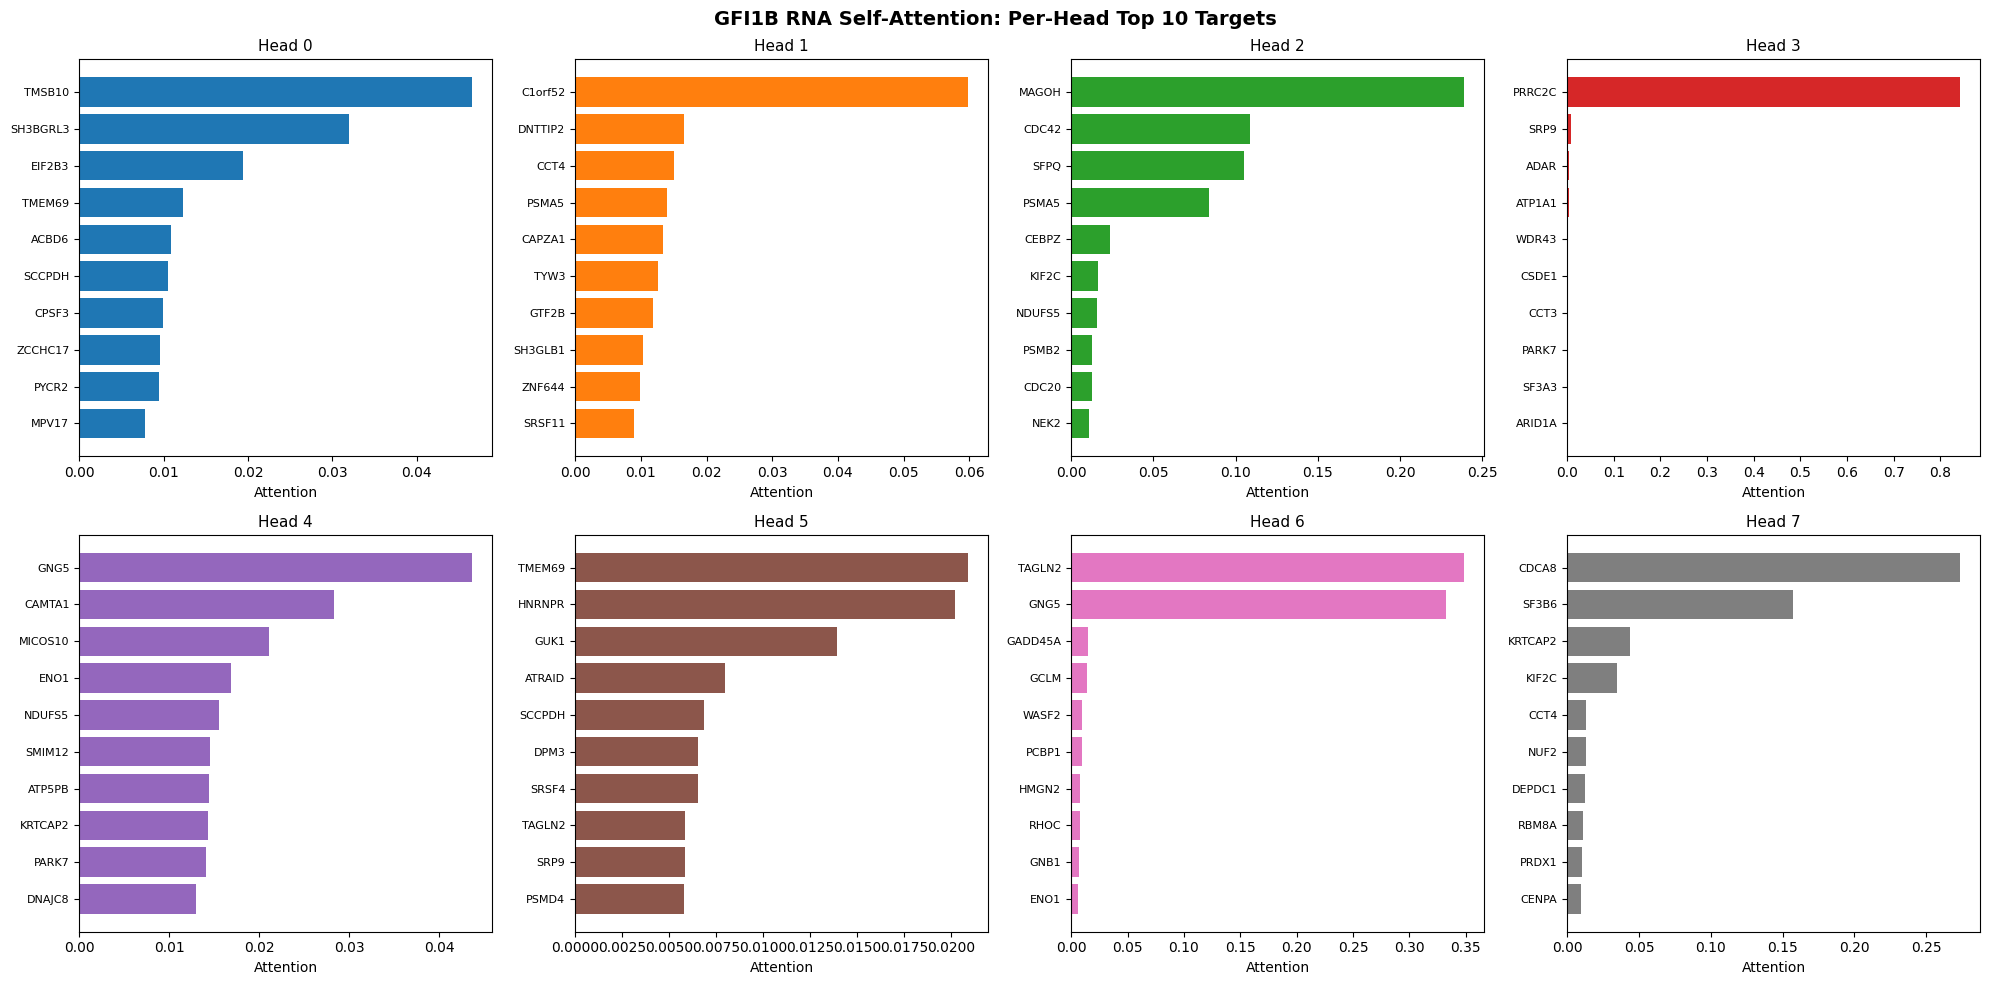

In [ ]:
# Per-head analysis: does each head capture different networks?
print("\nPer-Head GFI1B RNA Self-Attention")
nhead = rna_self_avg.shape[0]

if gfi1b_idx is not None:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for head in range(nhead):
        ax = axes[head]
        head_attn = rna_self_avg[head, gfi1b_idx, :]  # [2360]
        top_10 = np.argsort(head_attn)[-10:][::-1]
        top_names = [cdt_genes[i] for i in top_10]
        top_vals = head_attn[top_10]

        ax.barh(range(10), top_vals, color=plt.cm.tab10(head))
        ax.set_yticks(range(10))
        ax.set_yticklabels(top_names, fontsize=8)
        ax.set_title(f'Head {head}', fontsize=11)
        ax.invert_yaxis()
        ax.set_xlabel('Attention')

    plt.suptitle(f'GFI1B RNA Self-Attention: Per-Head Top 10 Targets',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_BASE / 'gfi1b_rna_self_per_head.png', dpi=150, bbox_inches='tight')
    plt.savefig(OUTPUT_BASE / 'gfi1b_rna_self_per_head.pdf', bbox_inches='tight')
    plt.show()

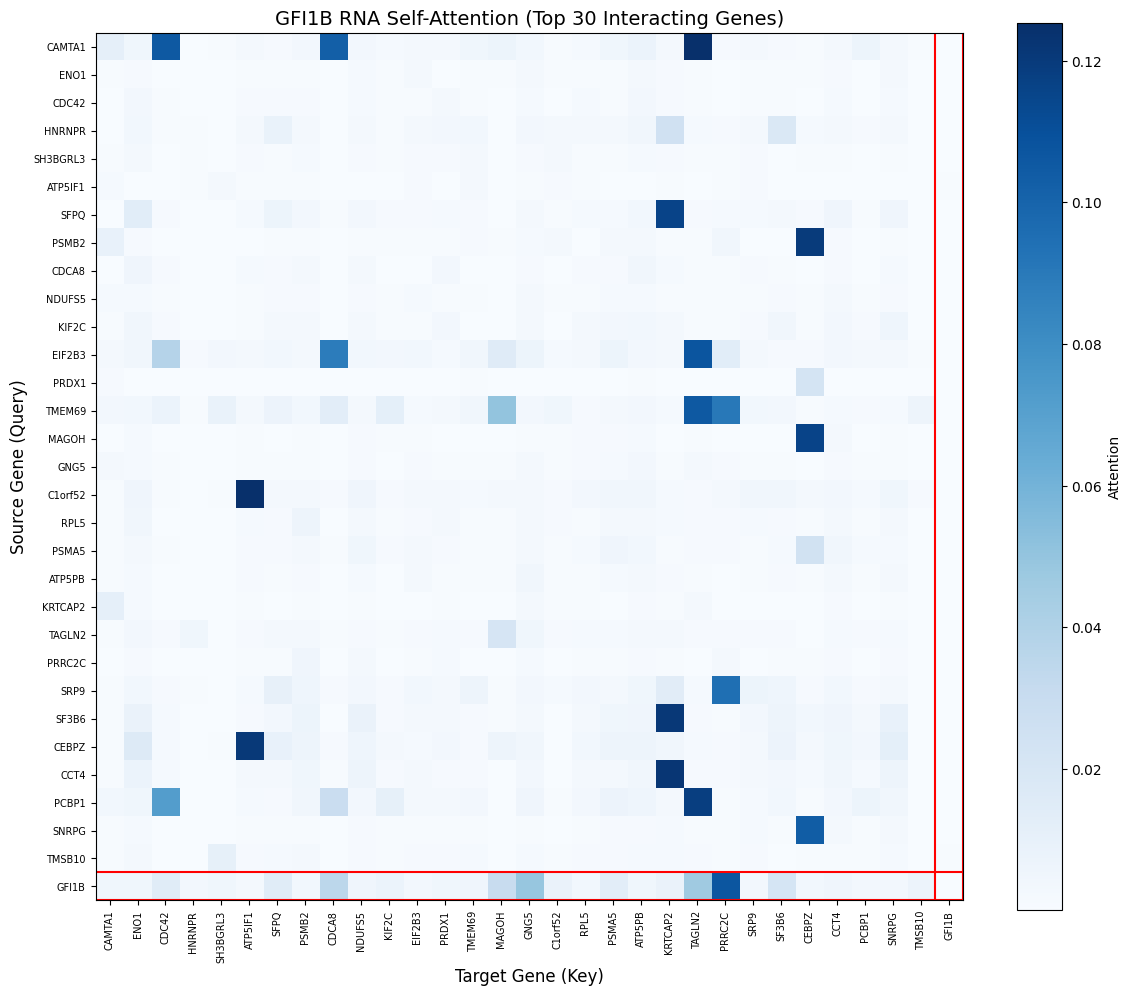

In [ ]:
# RNA Self-Attention 2D Heatmap for GFI1B
if gfi1b_idx is not None:
    combined_attn = gfi1b_attends_to + attends_to_gfi1b
    top_interacting = np.argsort(combined_attn)[-30:]  # Top 30
    if gfi1b_idx not in top_interacting:
        top_interacting = np.append(top_interacting, gfi1b_idx)
    top_interacting = np.sort(top_interacting)
    interacting_names = [cdt_genes[i] for i in top_interacting]

    rna_self_subset = rna_self_head_avg[np.ix_(top_interacting, top_interacting)]

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(rna_self_subset, cmap='Blues')
    ax.set_xticks(range(len(interacting_names)))
    ax.set_xticklabels(interacting_names, rotation=90, fontsize=7)
    ax.set_yticks(range(len(interacting_names)))
    ax.set_yticklabels(interacting_names, fontsize=7)
    ax.set_xlabel('Target Gene (Key)', fontsize=12)
    ax.set_ylabel('Source Gene (Query)', fontsize=12)

    # Highlight GFI1B
    gfi1b_local = np.where(top_interacting == gfi1b_idx)[0]
    if len(gfi1b_local) > 0:
        idx = gfi1b_local[0]
        ax.axhline(idx - 0.5, color='red', linewidth=1.5)
        ax.axhline(idx + 0.5, color='red', linewidth=1.5)
        ax.axvline(idx - 0.5, color='red', linewidth=1.5)
        ax.axvline(idx + 0.5, color='red', linewidth=1.5)

    plt.colorbar(im, label='Attention')
    plt.title('GFI1B RNA Self-Attention (Top 30 Interacting Genes)', fontsize=14)
    plt.tight_layout()
    plt.savefig(OUTPUT_BASE / 'gfi1b_rna_self_2d.png', dpi=150, bbox_inches='tight')
    plt.savefig(OUTPUT_BASE / 'gfi1b_rna_self_2d.pdf', bbox_inches='tight')
    plt.show()

## 7. CD52 Case Study: Drug Target Analysis

In [ ]:
# CD52 analysis (alemtuzumab target)
gene_name = 'CD52'

if gene_name in val_cells_by_gene:
    print(f"CD52 Case Study (alemtuzumab target)")
    print("=" * 60)

    cd52_cells = val_cells_by_gene[gene_name]
    n_sample = min(20, len(cd52_cells))
    cd52_dna = tss_enformer_emb[tss_gene_to_enformer[gene_name]]

    cd52_rna_self_attns = []
    for cell_idx in tqdm(cd52_cells[:n_sample], desc="Extracting CD52 attention"):
        result = extract_attention_maps(model, cd52_dna, tss_cell_expr[cell_idx], device)
        cd52_rna_self_attns.append(result['rna_self'][0])

    cd52_rna_self_avg = np.mean(cd52_rna_self_attns, axis=0).mean(axis=0)  # [2360, 2360]

    cd52_idx = gene_to_idx.get('CD52')
    if cd52_idx is not None:
        cd52_attends_to = cd52_rna_self_avg[cd52_idx, :]
        top_20 = np.argsort(cd52_attends_to)[-20:][::-1]

        print(f"\nTop 20 genes CD52 attends to:")
        for rank, idx in enumerate(top_20):
            print(f"  {rank+1:2d}. {cdt_genes[idx]:<12} {cd52_attends_to[idx]:.6f}")

        # Self-effect prediction
        cd52_mask = all_gene_labels == 'CD52' if 'all_gene_labels' in dir() else None
        print(f"\n  CD52 cis-effect (self-knockdown): Gene index {cd52_idx}")
else:
    print(f"  {gene_name} not in val genes, skipping.")

CD52 Case Study (alemtuzumab target)


Extracting CD52 attention: 100%|██████████| 20/20 [00:04<00:00,  4.36it/s]



Top 20 genes CD52 attends to:
   1. TAGLN2       0.119749
   2. CDC42        0.052528
   3. ATP1A1       0.048450
   4. MAGOH        0.048115
   5. CDCA8        0.044458
   6. KIF2C        0.015358
   7. GUK1         0.013358
   8. COX7A2L      0.008797
   9. CAMTA1       0.007122
  10. KIF14        0.006911
  11. JTB          0.006493
  12. SRSF4        0.006403
  13. CENPA        0.006176
  14. TYW3         0.005742
  15. PSMA5        0.005516
  16. GNG5         0.005476
  17. HTRA2        0.005026
  18. PCBP1        0.004829
  19. DAP3         0.004776
  20. PRDX6        0.004744

  CD52 cis-effect (self-knockdown): Gene index 345


## 8. DNA->RNA Cross-Attention Analysis

In [ ]:
# Cross-attention analysis: which DNA positions influence which genes
print("DNA->RNA Cross-Attention Analysis")
print("=" * 60)

# Collect cross-attention for all val genes
cross_attn_by_gene = {}

for gene in tss_val_genes:
    cells = val_cells_by_gene[gene]
    n_sample = min(10, len(cells))
    dna = tss_enformer_emb[tss_gene_to_enformer[gene]]

    cross_attns = []
    for cell_idx in cells[:n_sample]:
        result = extract_attention_maps(model, dna, tss_cell_expr[cell_idx], device)
        cross_attns.append(result['cross_attn'])  # [nhead, 2360, 896]

    cross_attn_avg = np.mean(cross_attns, axis=0)  # [nhead, 2360, 896]
    cross_attn_by_gene[gene] = cross_attn_avg
    print(f"  {gene}: cross-attention extracted ({n_sample} cells)")

print("Done!")

DNA->RNA Cross-Attention Analysis
  CD44: cross-attention extracted (10 cells)
  CD52: cross-attention extracted (10 cells)
  GFI1B: cross-attention extracted (10 cells)
  TFRC: cross-attention extracted (10 cells)
  TNFSF9: cross-attention extracted (10 cells)
Done!


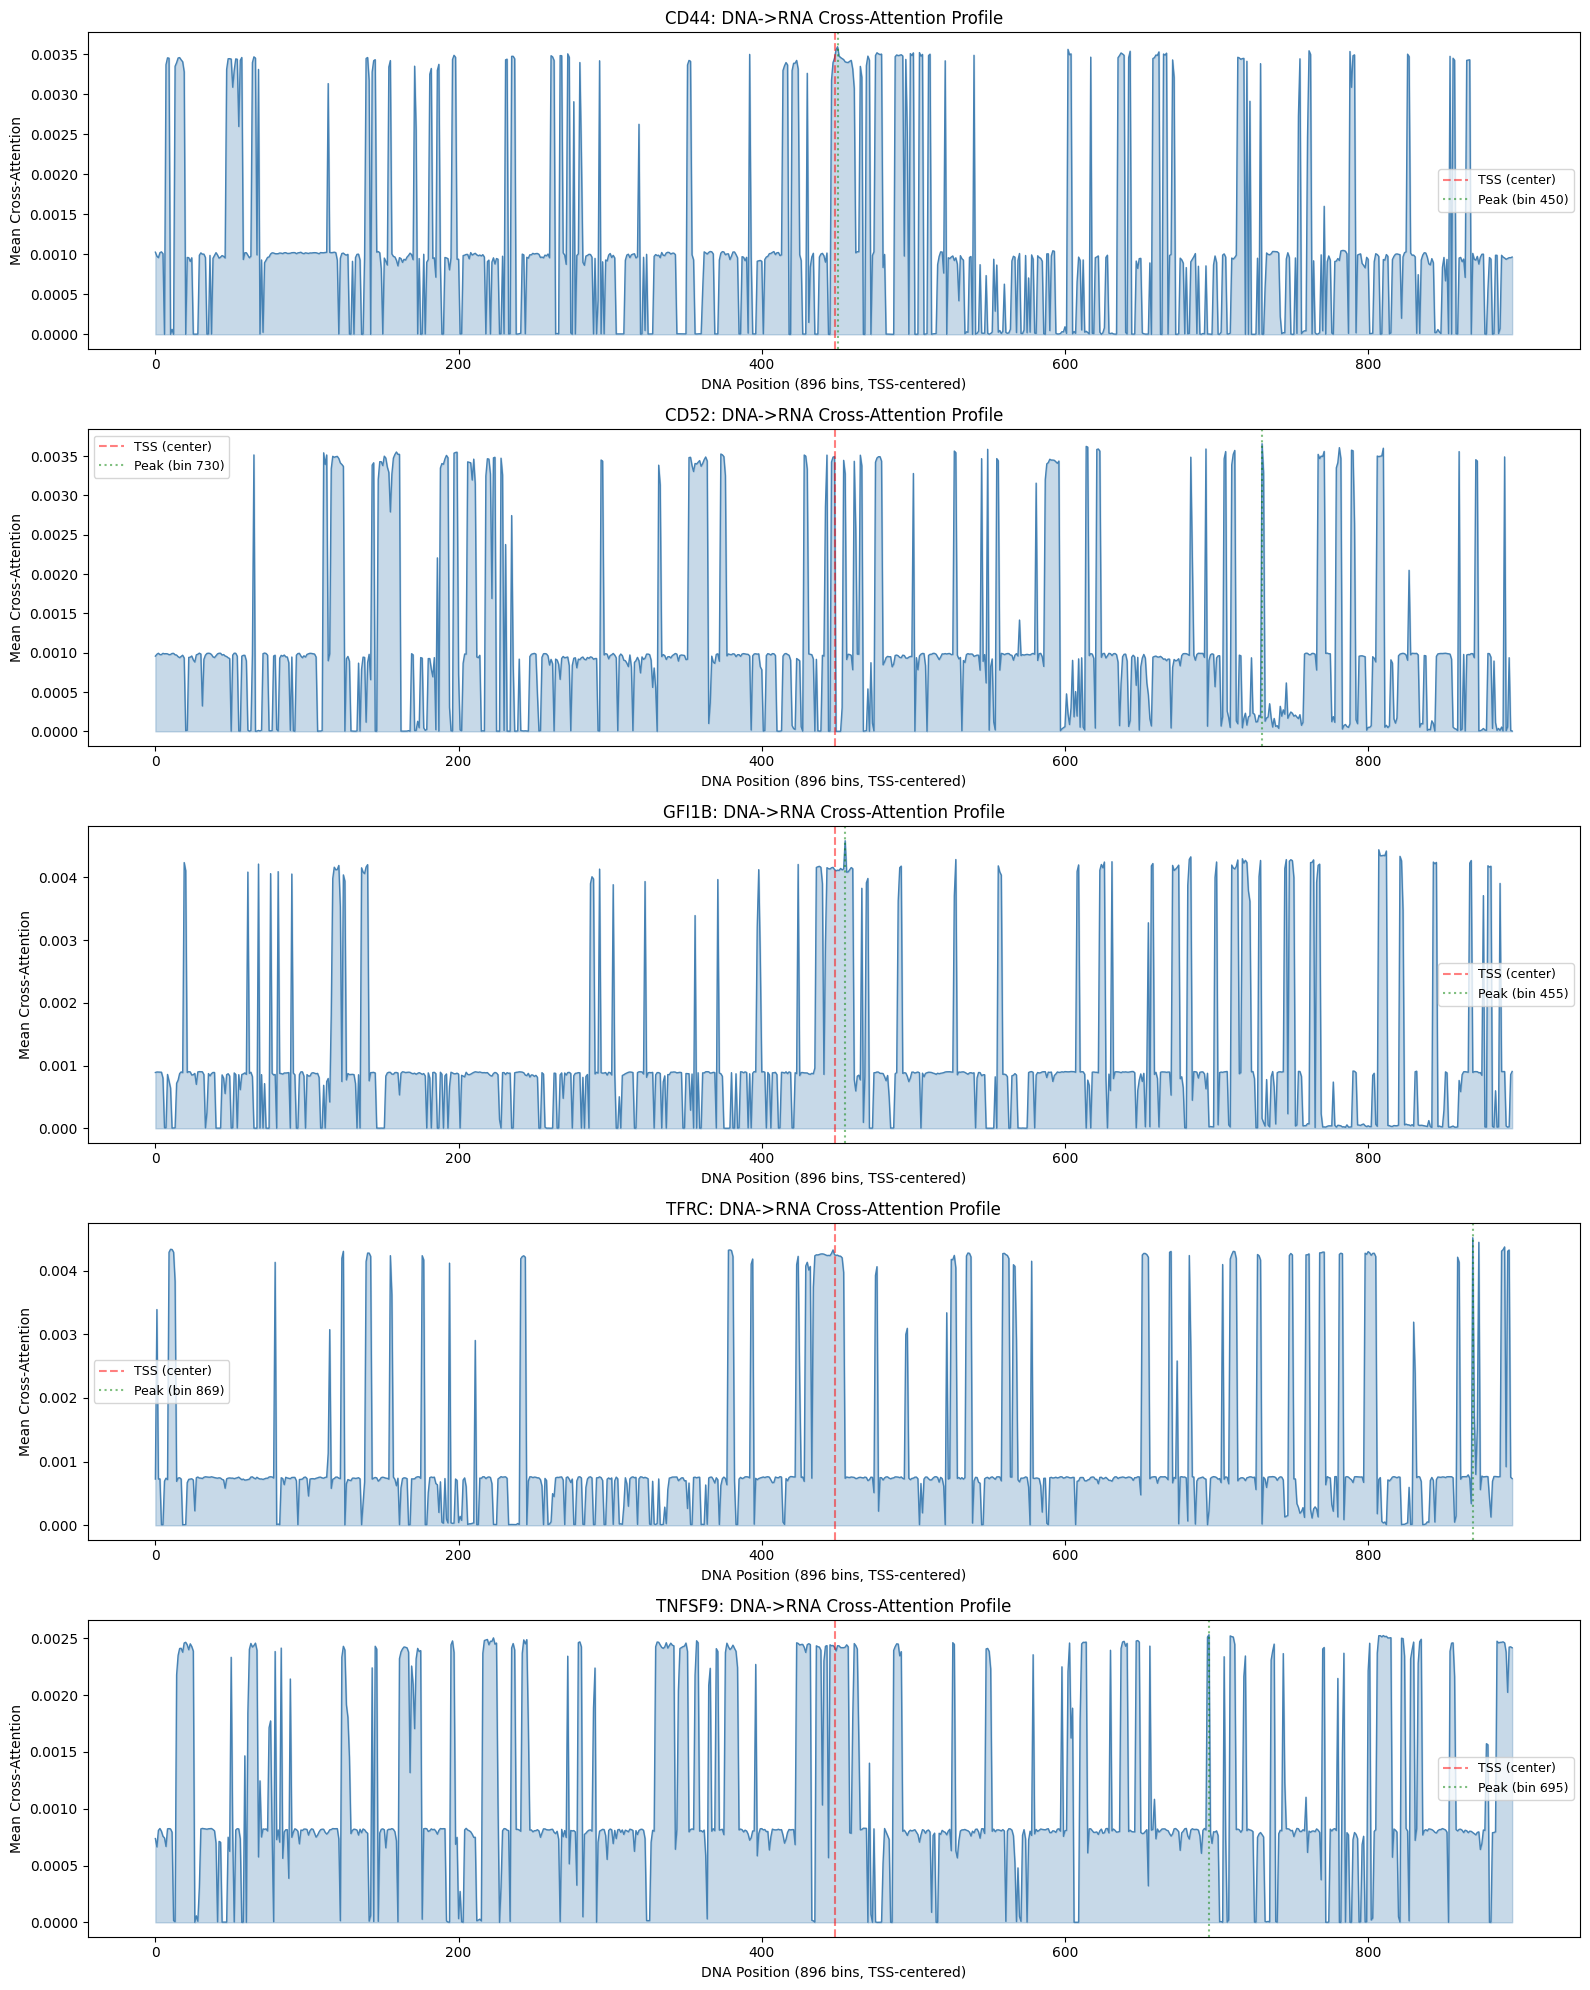

In [ ]:
# 1D Cross-Attention Profiles: which DNA bins each gene attends to
fig, axes = plt.subplots(len(tss_val_genes), 1, figsize=(16, 4 * len(tss_val_genes)))
if len(tss_val_genes) == 1:
    axes = [axes]

for i, gene in enumerate(tss_val_genes):
    ax = axes[i]
    cross_attn = cross_attn_by_gene[gene]  # [nhead, 2360, 896]
    # Average over heads, then mean over all output genes
    gene_avg = cross_attn.mean(axis=0).mean(axis=0)  # [896]

    ax.plot(gene_avg, linewidth=1, color='steelblue')
    ax.fill_between(range(896), gene_avg, alpha=0.3, color='steelblue')
    ax.axvline(448, color='red', linestyle='--', alpha=0.5, label='TSS (center)')

    # Mark peak
    peak_pos = np.argmax(gene_avg)
    ax.axvline(peak_pos, color='green', linestyle=':', alpha=0.5,
               label=f'Peak (bin {peak_pos})')

    ax.set_xlabel('DNA Position (896 bins, TSS-centered)')
    ax.set_ylabel('Mean Cross-Attention')
    ax.set_title(f'{gene}: DNA->RNA Cross-Attention Profile')
    ax.legend(fontsize=9)

#plt.suptitle('DNA->RNA Cross-Attention: TSS Perturbations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'cross_attention_profiles.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'cross_attention_profiles.pdf', bbox_inches='tight')
plt.show()

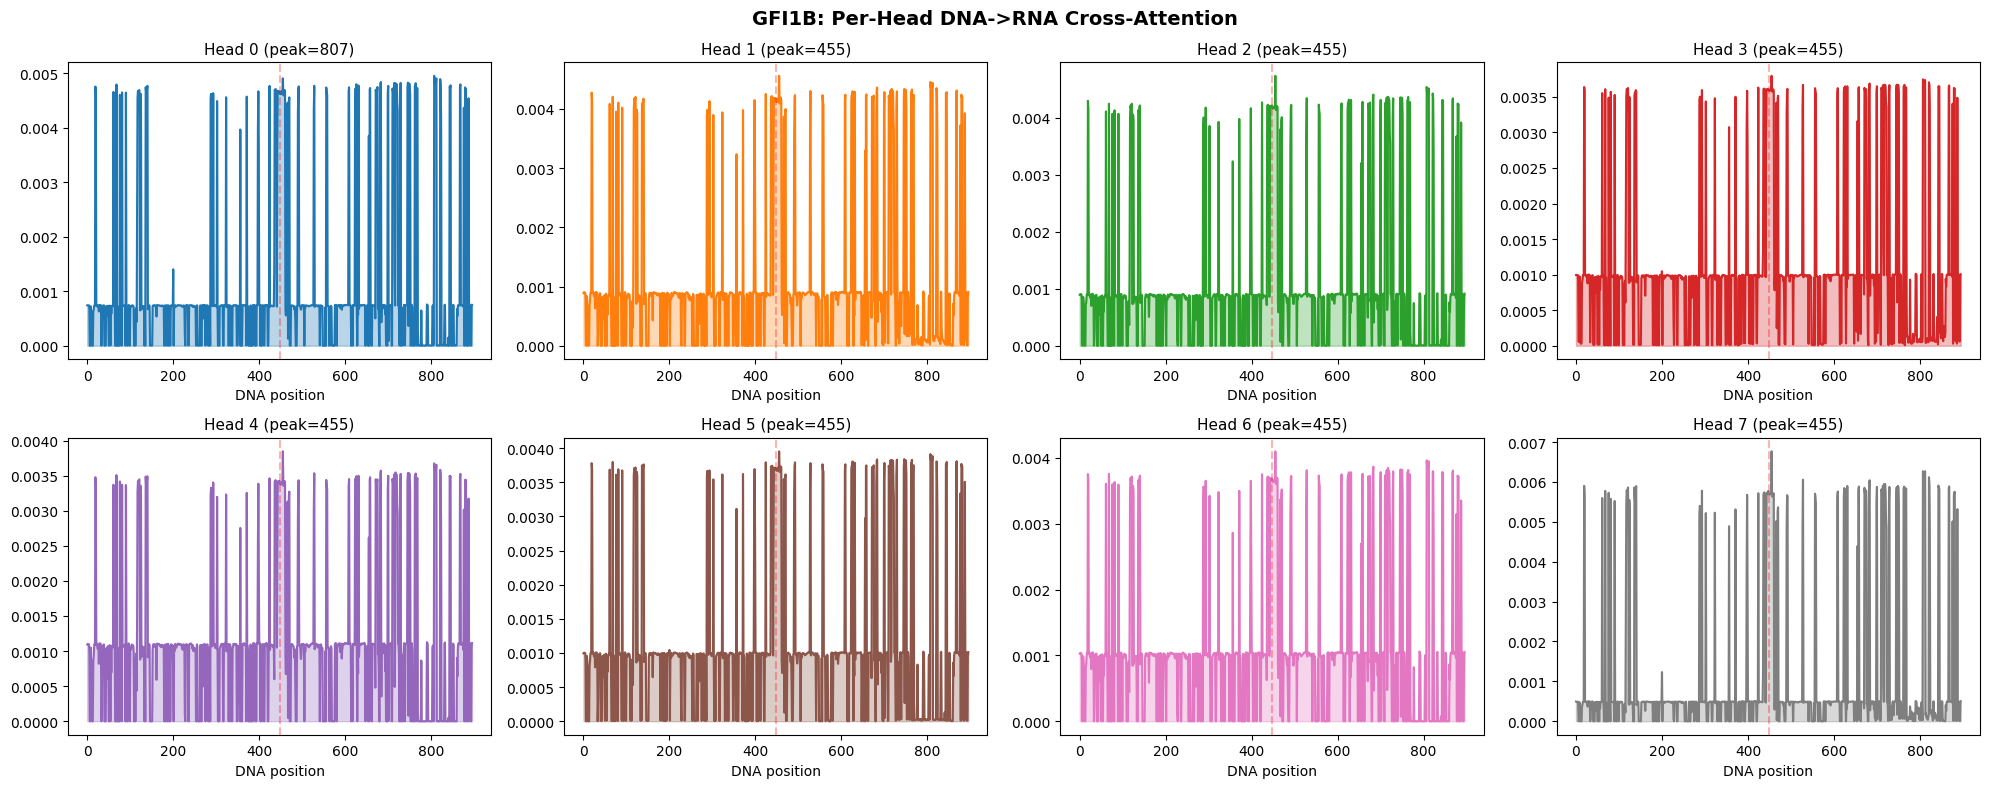

In [ ]:
# Per-head cross-attention for GFI1B
gene = 'GFI1B'
if gene in cross_attn_by_gene:
    cross_attn = cross_attn_by_gene[gene]  # [nhead, 2360, 896]
    nhead = cross_attn.shape[0]

    # Mean over genes for each head
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()

    for head in range(nhead):
        ax = axes[head]
        head_profile = cross_attn[head].mean(axis=0)  # [896]
        ax.plot(head_profile, color=plt.cm.tab10(head))
        ax.fill_between(range(896), head_profile, alpha=0.3, color=plt.cm.tab10(head))
        ax.axvline(448, color='red', linestyle='--', alpha=0.3)
        peak = np.argmax(head_profile)
        ax.set_title(f'Head {head} (peak={peak})', fontsize=11)
        ax.set_xlabel('DNA position')

    plt.suptitle(f'{gene}: Per-Head DNA->RNA Cross-Attention', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_BASE / f'{gene.lower()}_cross_attn_per_head.png', dpi=150, bbox_inches='tight')
    plt.savefig(OUTPUT_BASE / f'{gene.lower()}_cross_attn_per_head.pdf', bbox_inches='tight')
    plt.show()

## 9. DNA Self-Attention Analysis

DNA Self-Attention Analysis


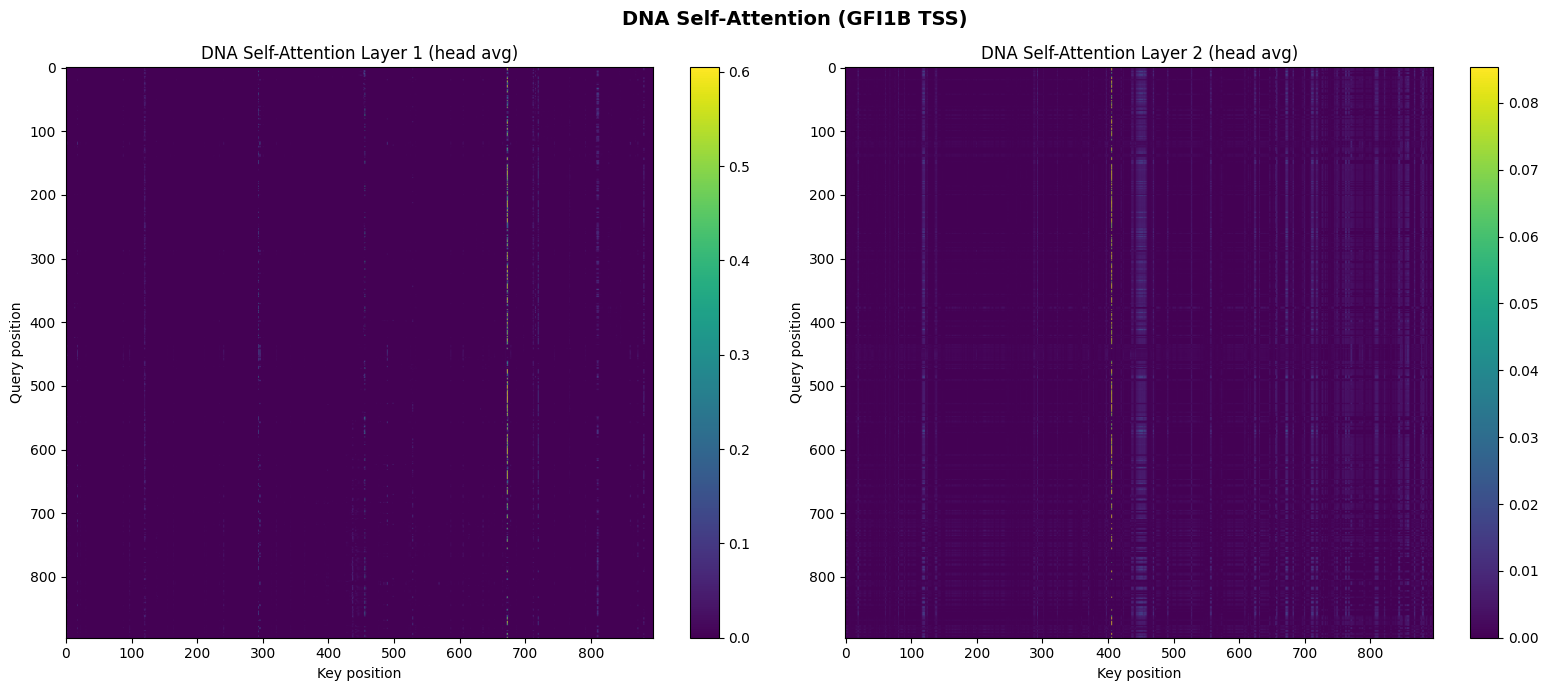

In [ ]:
# DNA Self-Attention: 2 layers x 8 heads
print("DNA Self-Attention Analysis")
print("=" * 60)

# Extract from GFI1B (representative)
gene = 'GFI1B'
dna = tss_enformer_emb[tss_gene_to_enformer[gene]]
cell_idx = val_cells_by_gene[gene][0]
result = extract_attention_maps(model, dna, tss_cell_expr[cell_idx], device)

# Layer 1 vs Layer 2
dna_self_l1 = result['dna_self'][0]  # [nhead, 896, 896]
dna_self_l2 = result['dna_self'][1]  # [nhead, 896, 896]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Layer 1 - head average
ax = axes[0]
im = ax.imshow(dna_self_l1.mean(axis=0), cmap='viridis', aspect='auto')
ax.set_title('DNA Self-Attention Layer 1 (head avg)', fontsize=12)
ax.set_xlabel('Key position')
ax.set_ylabel('Query position')
plt.colorbar(im, ax=ax)

# Layer 2 - head average
ax = axes[1]
im = ax.imshow(dna_self_l2.mean(axis=0), cmap='viridis', aspect='auto')
ax.set_title('DNA Self-Attention Layer 2 (head avg)', fontsize=12)
ax.set_xlabel('Key position')
ax.set_ylabel('Query position')
plt.colorbar(im, ax=ax)

plt.suptitle(f'DNA Self-Attention ({gene} TSS)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'dna_self_attention_layers.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'dna_self_attention_layers.pdf', bbox_inches='tight')
plt.show()

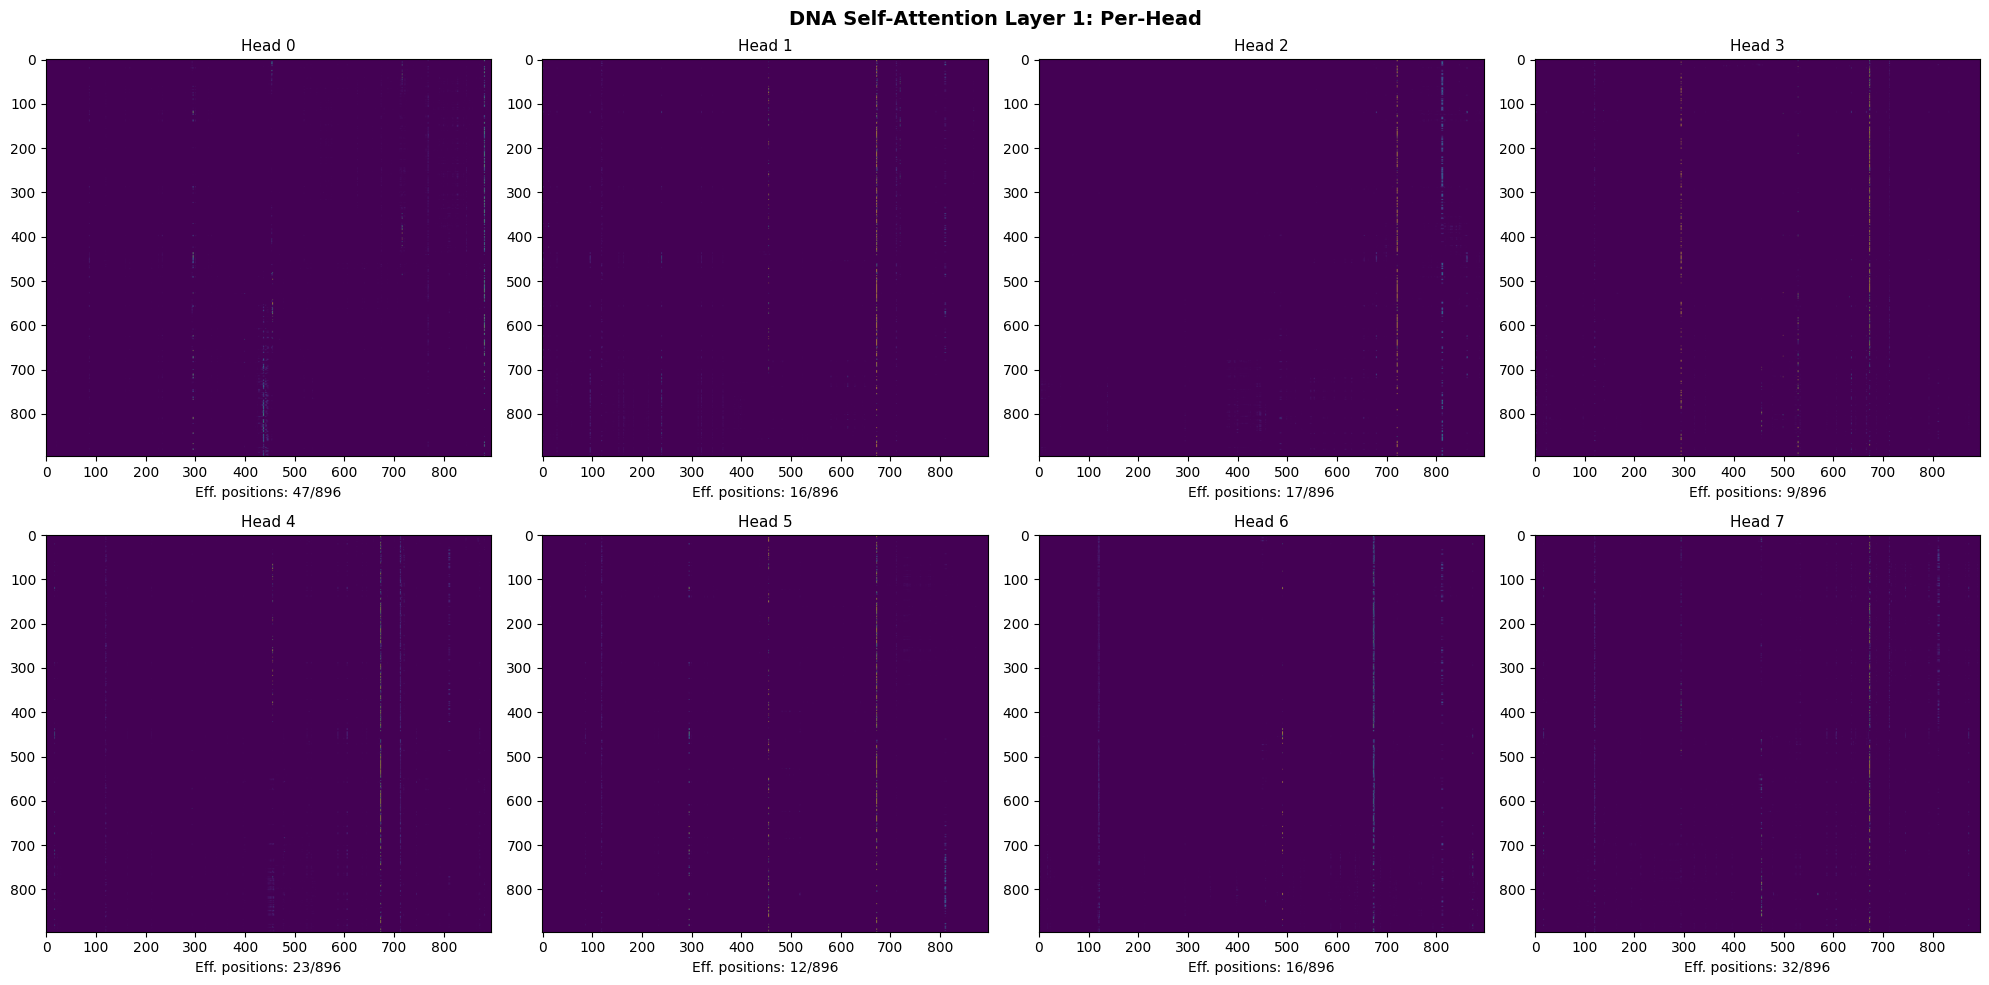

In [ ]:
# Per-head DNA Self-Attention (Layer 1)
nhead = dna_self_l1.shape[0]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for head in range(nhead):
    ax = axes[head]
    im = ax.imshow(dna_self_l1[head], cmap='viridis', aspect='auto')
    ax.set_title(f'Head {head}', fontsize=11)

    # Compute effective number of attended positions (entropy)
    attn_flat = dna_self_l1[head].mean(axis=0)  # Mean query
    attn_flat = attn_flat + 1e-10
    attn_flat = attn_flat / attn_flat.sum()
    entropy = -np.sum(attn_flat * np.log(attn_flat))
    effective_n = np.exp(entropy)
    ax.set_xlabel(f'Eff. positions: {effective_n:.0f}/896')

plt.suptitle('DNA Self-Attention Layer 1: Per-Head', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'dna_self_attention_per_head.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'dna_self_attention_per_head.pdf', bbox_inches='tight')
plt.show()

## 10. VCE Pooling Attention

In [ ]:
# VCE Pooling Attention Analysis
print("VCE Pooling Attention")
print("=" * 60)

# Collect VCE attention across val genes
vce_dna_by_gene = {}  # [4, 1, 896]
vce_rna_by_gene = {}  # [4, 1, 2360]

for gene in tss_val_genes:
    cells = val_cells_by_gene[gene]
    n_sample = min(10, len(cells))
    dna = tss_enformer_emb[tss_gene_to_enformer[gene]]

    vce_dna_list = []
    vce_rna_list = []
    for cell_idx in cells[:n_sample]:
        result = extract_attention_maps(model, dna, tss_cell_expr[cell_idx], device)
        vce_dna_list.append(result['vce_dna'])  # [4, 1, 896]
        vce_rna_list.append(result['vce_rna'])  # [4, 1, 2360]

    vce_dna_by_gene[gene] = np.mean(vce_dna_list, axis=0)
    vce_rna_by_gene[gene] = np.mean(vce_rna_list, axis=0)

print("VCE attention extracted for all val genes")

VCE Pooling Attention
VCE attention extracted for all val genes


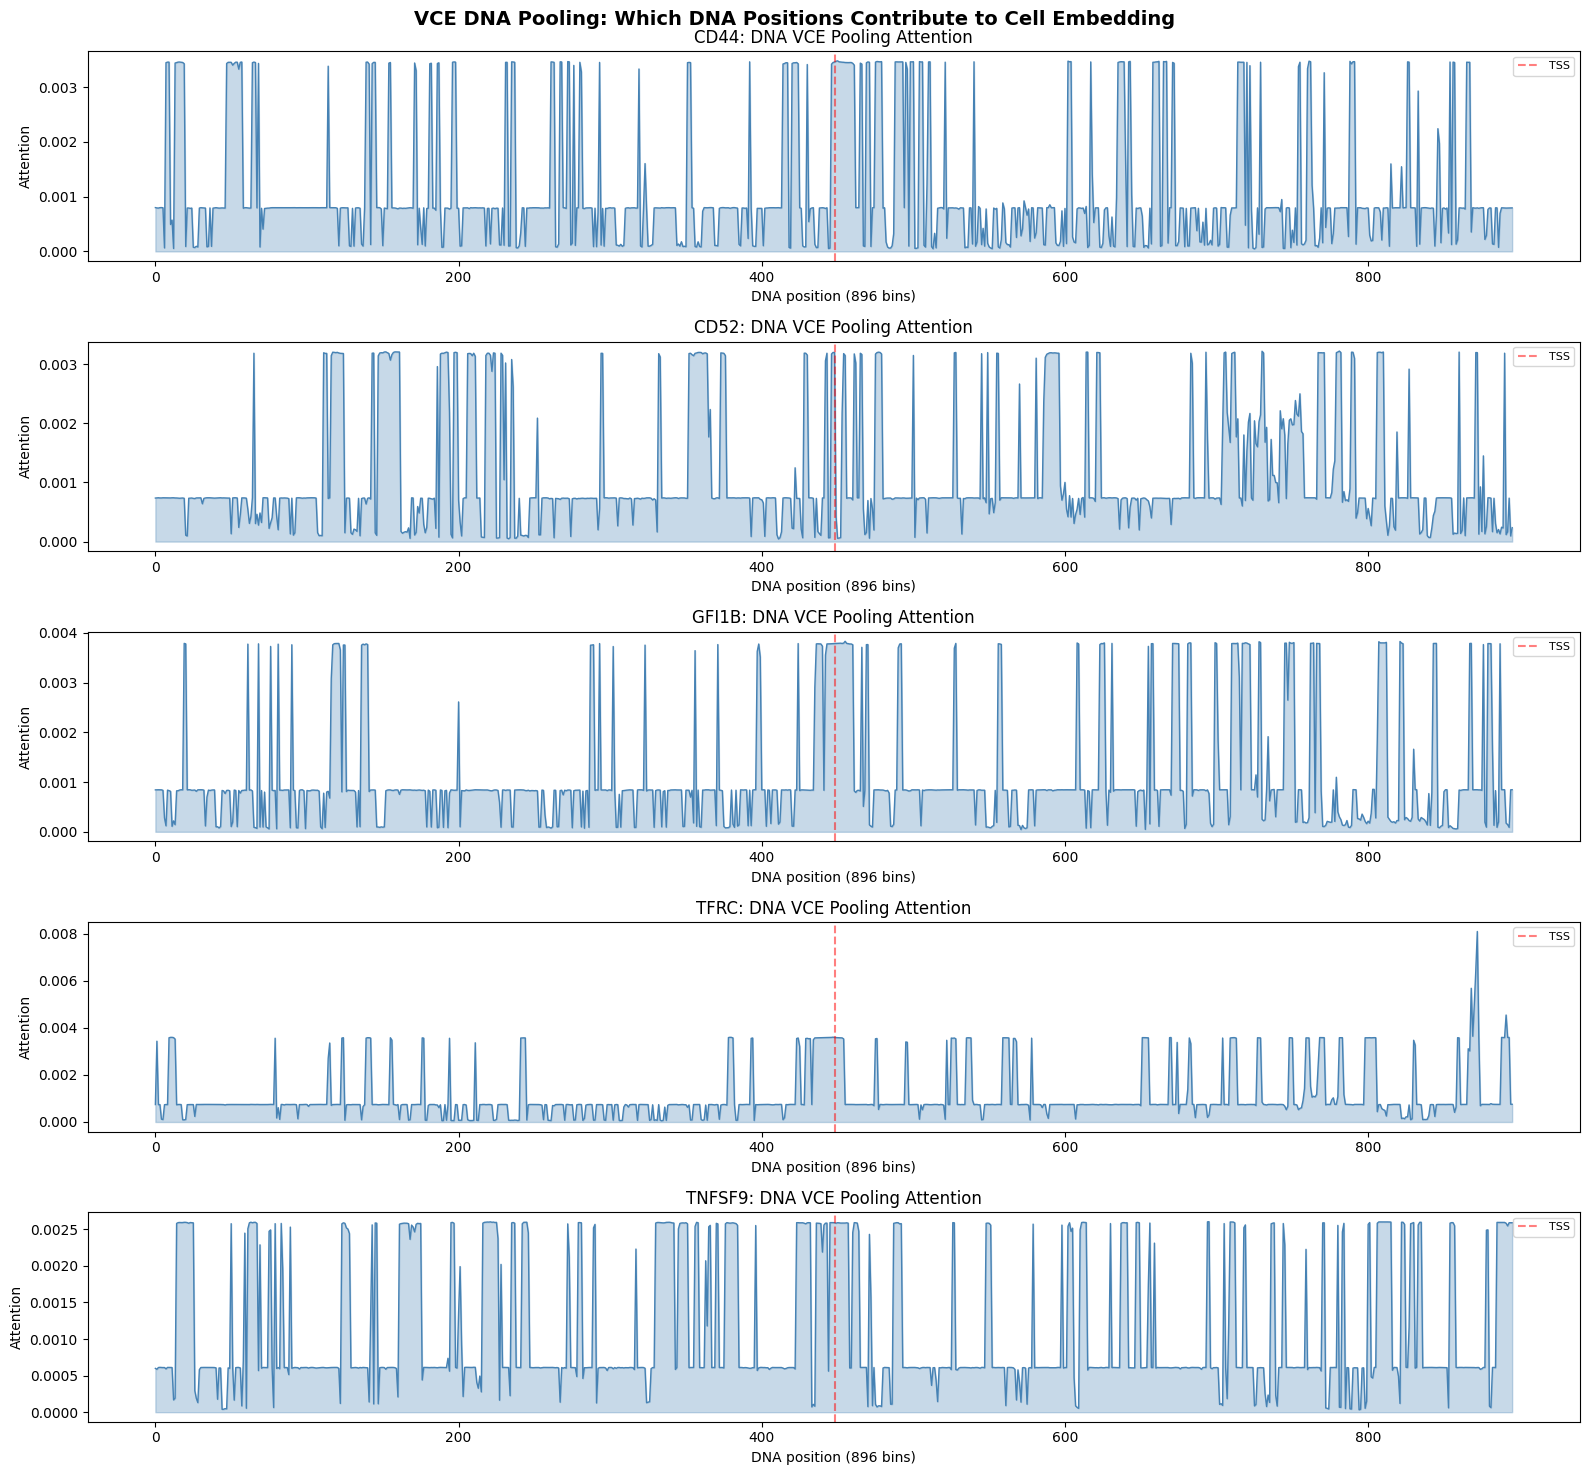

In [ ]:
# VCE DNA pooling: which DNA positions contribute most to VCE
fig, axes = plt.subplots(len(tss_val_genes), 1, figsize=(16, 3 * len(tss_val_genes)))
if len(tss_val_genes) == 1:
    axes = [axes]

for i, gene in enumerate(tss_val_genes):
    ax = axes[i]
    vce_dna = vce_dna_by_gene[gene]  # [4, 1, 896]
    vce_dna_avg = vce_dna.mean(axis=0).squeeze()  # [896]

    ax.plot(vce_dna_avg, linewidth=1, color='steelblue')
    ax.fill_between(range(896), vce_dna_avg, alpha=0.3, color='steelblue')
    ax.axvline(448, color='red', linestyle='--', alpha=0.5, label='TSS')
    ax.set_title(f'{gene}: DNA VCE Pooling Attention')
    ax.set_xlabel('DNA position (896 bins)')
    ax.set_ylabel('Attention')
    ax.legend(fontsize=8)

plt.suptitle('VCE DNA Pooling: Which DNA Positions Contribute to Cell Embedding',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'vce_dna_pooling.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'vce_dna_pooling.pdf', bbox_inches='tight')
plt.show()

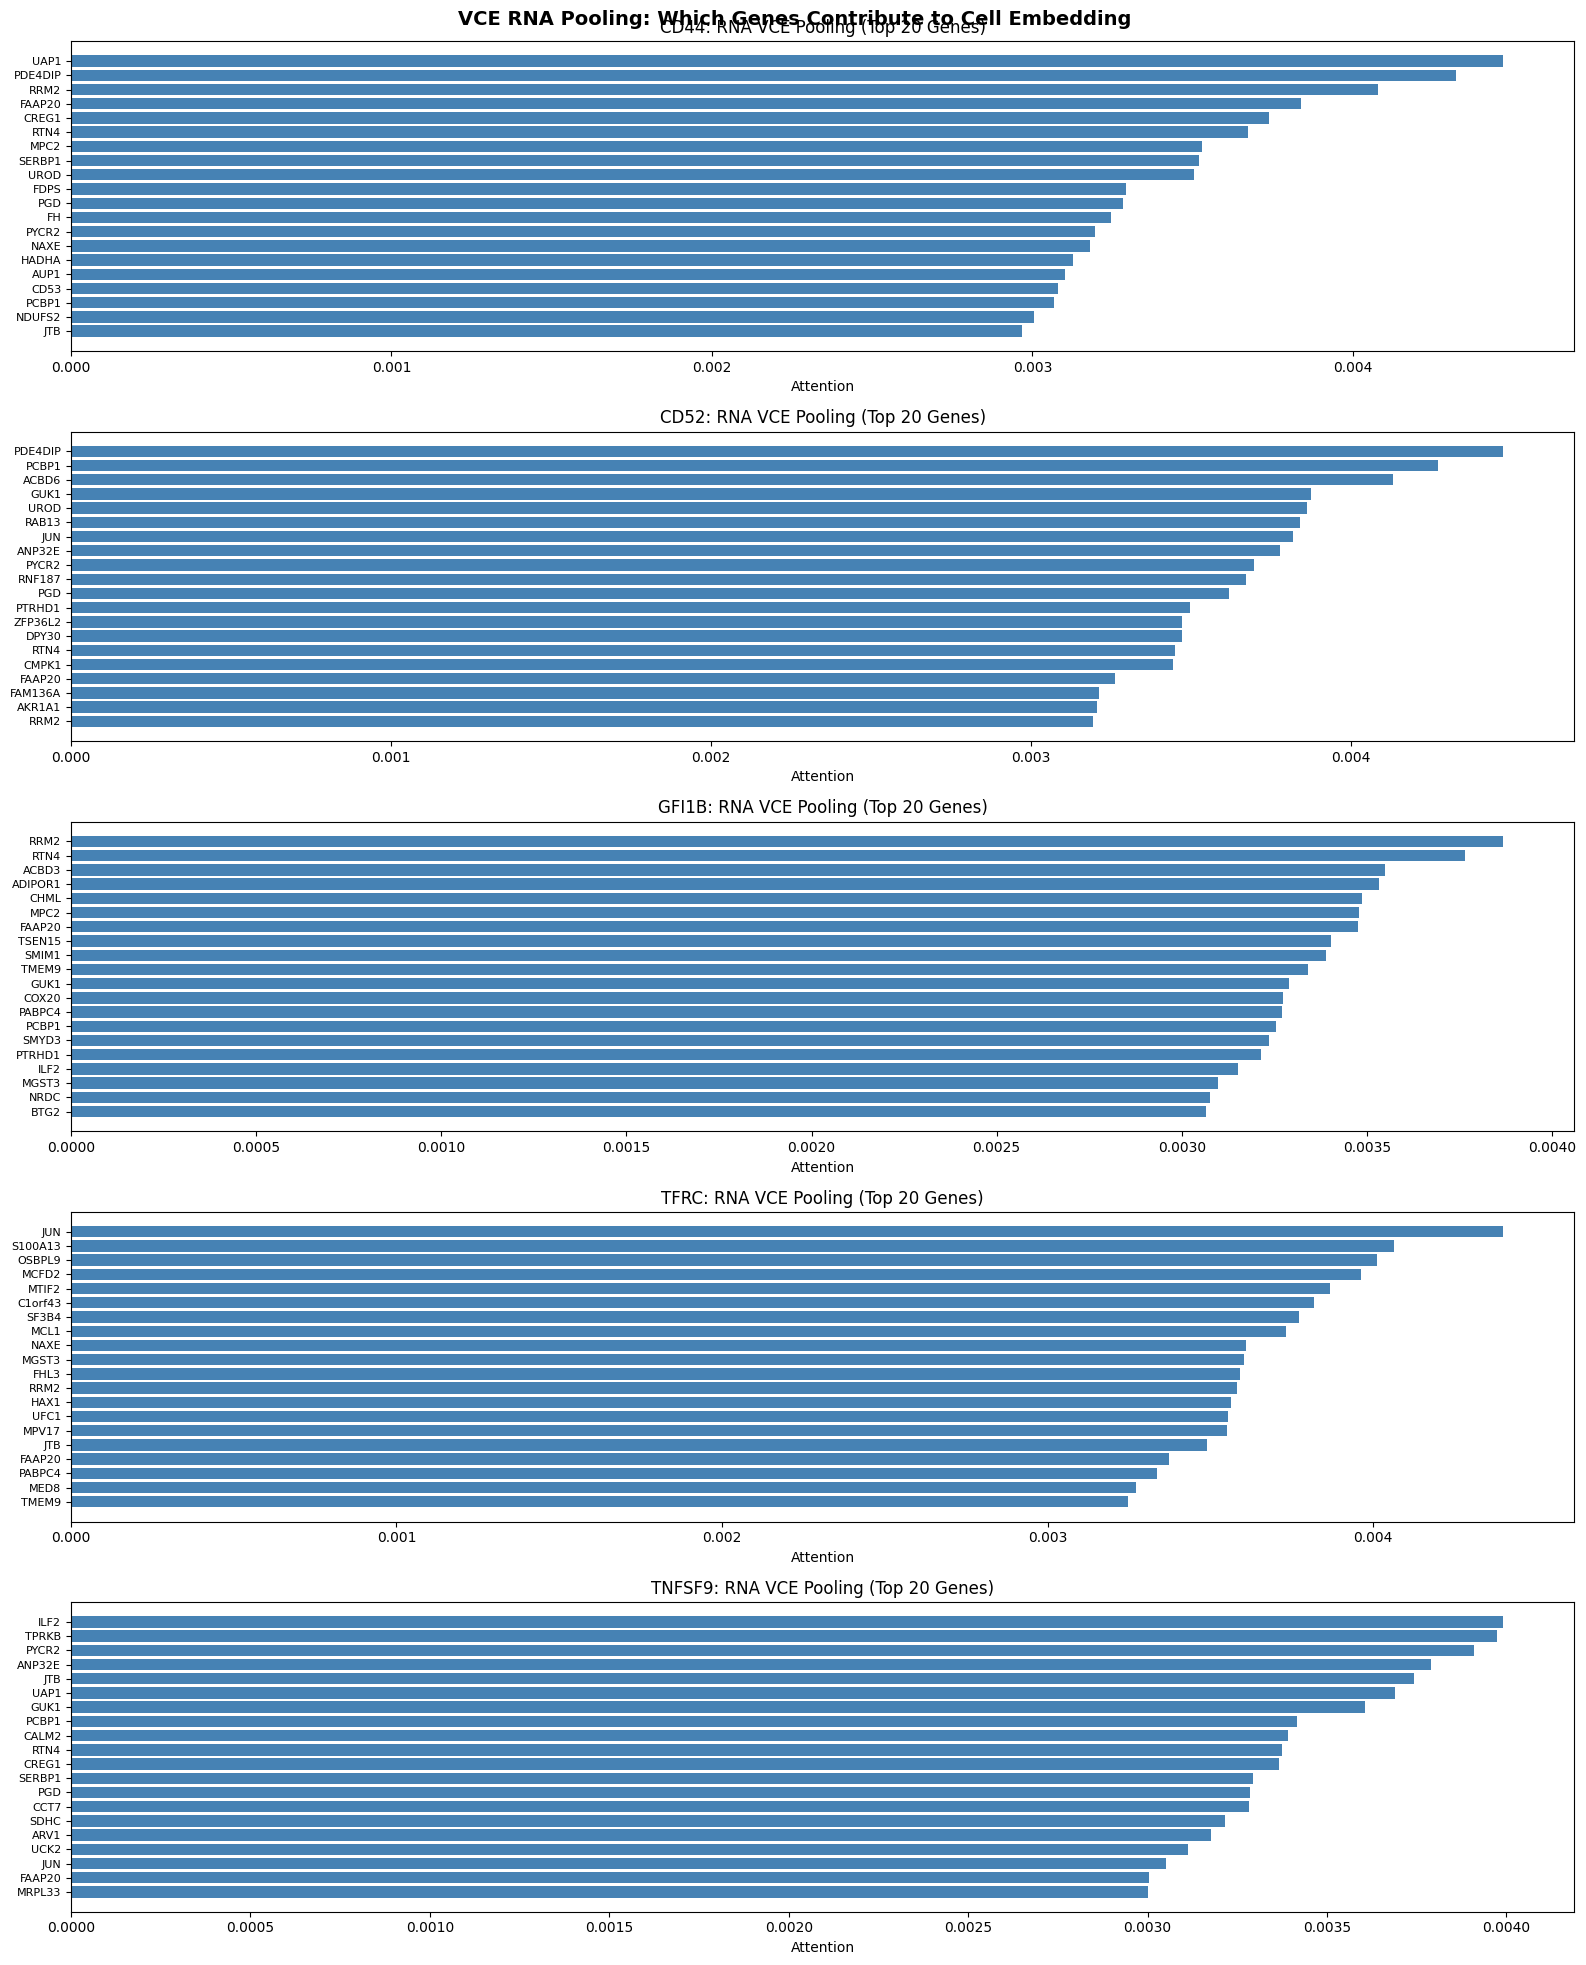

In [ ]:
# VCE RNA pooling: which genes contribute most to VCE
fig, axes = plt.subplots(len(tss_val_genes), 1, figsize=(16, 4 * len(tss_val_genes)))
if len(tss_val_genes) == 1:
    axes = [axes]

for i, gene in enumerate(tss_val_genes):
    ax = axes[i]
    vce_rna = vce_rna_by_gene[gene]  # [4, 1, 2360]
    vce_rna_avg = vce_rna.mean(axis=0).squeeze()  # [2360]

    # Top 20 contributing genes
    top_20 = np.argsort(vce_rna_avg)[-20:][::-1]
    top_names = [cdt_genes[j] for j in top_20]
    top_vals = vce_rna_avg[top_20]

    ax.barh(range(20), top_vals, color='steelblue')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'{gene}: RNA VCE Pooling (Top 20 Genes)')
    ax.set_xlabel('Attention')

plt.suptitle('VCE RNA Pooling: Which Genes Contribute to Cell Embedding',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'vce_rna_pooling.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'vce_rna_pooling.pdf', bbox_inches='tight')
plt.show()

## 11. Cell-to-Cell Attention Variation

In [ ]:
# Cell-to-cell variation in attention patterns
print("Cell-to-Cell Attention Variation")
print("=" * 60)

gene = 'GFI1B'
gfi1b_idx_check = gene_to_idx.get(gene)
cells = val_cells_by_gene[gene]

if gfi1b_idx_check is not None:
    n_compare = min(20, len(cells))
    dna = tss_enformer_emb[tss_gene_to_enformer[gene]]

    # Extract RNA self-attention for multiple cells
    cell_rna_attns = []  # [n_cells, 2360] - GFI1B's attention to each gene

    for cell_idx in tqdm(cells[:n_compare], desc="Cell-to-cell attention"):
        result = extract_attention_maps(model, dna, tss_cell_expr[cell_idx], device)
        rna_self = result['rna_self'][0].mean(axis=0)  # [2360, 2360] head avg
        cell_rna_attns.append(rna_self[gfi1b_idx_check, :])  # [2360]

    cell_rna_attns = np.stack(cell_rna_attns)  # [n_cells, 2360]

    # Compute cell-cell correlation of attention patterns
    n_cells_cmp = cell_rna_attns.shape[0]
    cell_corr = np.zeros((n_cells_cmp, n_cells_cmp))
    for i in range(n_cells_cmp):
        for j in range(n_cells_cmp):
            cell_corr[i, j], _ = pearsonr(cell_rna_attns[i], cell_rna_attns[j])

    print(f"  Cell-cell attention correlation:")
    print(f"    Mean: {cell_corr[np.triu_indices(n_cells_cmp, k=1)].mean():.4f}")
    print(f"    Std:  {cell_corr[np.triu_indices(n_cells_cmp, k=1)].std():.4f}")
    print(f"    Min:  {cell_corr[np.triu_indices(n_cells_cmp, k=1)].min():.4f}")
else:
    print(f"  {gene} not in CDT {N_GENES}-gene list")
    print(f"  -> Skipping RNA Self-Attention cell-to-cell variation")
    print(f"  -> Cross-Attention cell variation can still be analyzed")
    print(f"  -> Include in Stage 2 (9,300 genes) for full analysis")
    cell_rna_attns = np.array([])
    cell_corr = None

Cell-to-Cell Attention Variation


Cell-to-cell attention: 100%|██████████| 20/20 [00:04<00:00,  4.24it/s]

  Cell-cell attention correlation:
    Mean: 0.8249
    Std:  0.1218
    Min:  0.5042


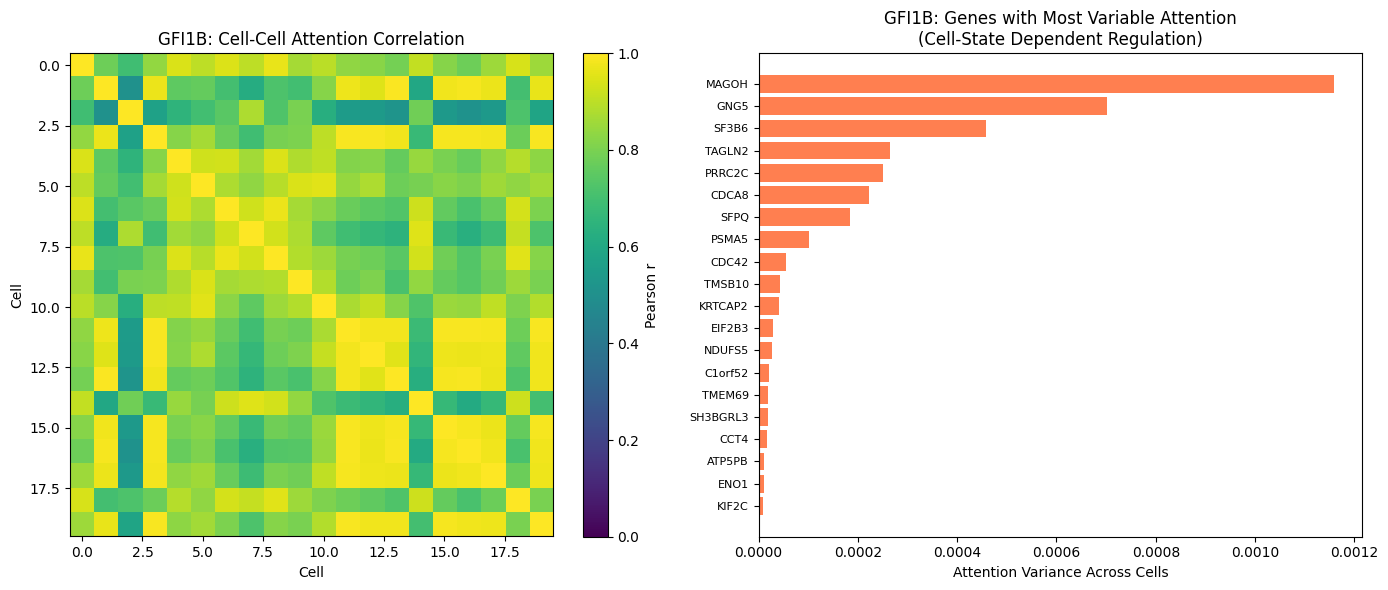


CDT discovers cell-specific regulatory networks:
  Different cells show different attention patterns for GFI1B


In [ ]:
# Plot cell-cell attention correlation matrix
if cell_corr is not None and cell_rna_attns.size > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Correlation matrix
    ax = axes[0]
    im = ax.imshow(cell_corr, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'{gene}: Cell-Cell Attention Correlation')
    ax.set_xlabel('Cell')
    ax.set_ylabel('Cell')
    plt.colorbar(im, ax=ax, label='Pearson r')

    # Per-gene attention variance across cells
    ax = axes[1]
    attn_variance = cell_rna_attns.var(axis=0)  # [2360] variance per gene
    top_variable = np.argsort(attn_variance)[-20:][::-1]
    top_names = [cdt_genes[j] for j in top_variable]
    top_vars = attn_variance[top_variable]

    ax.barh(range(20), top_vars, color='coral')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'{gene}: Genes with Most Variable Attention\n(Cell-State Dependent Regulation)')
    ax.set_xlabel('Attention Variance Across Cells')

    plt.tight_layout()
    plt.savefig(OUTPUT_BASE / 'cell_attention_variation.png', dpi=150, bbox_inches='tight')
    plt.savefig(OUTPUT_BASE / 'cell_attention_variation.pdf', bbox_inches='tight')
    plt.show()

    print(f"\nCDT discovers cell-specific regulatory networks:")
    print(f"  Different cells show different attention patterns for {gene}")
else:
    print(f"  Skipping cell-cell attention visualization ({gene} not in CDT gene list)")
    print(f"  -> Available in Stage 2 with 9,300 genes")

## 12. Per-Head Specialization Summary

In [ ]:
# Per-head specialization: what does each head capture?
print("Per-Head Specialization Summary")
print("=" * 60)

# Collect per-head top genes across all val genes
head_specialization = {}

for gene in tss_val_genes:
    cells = val_cells_by_gene[gene]
    dna = tss_enformer_emb[tss_gene_to_enformer[gene]]
    cell_idx = cells[0]
    result = extract_attention_maps(model, dna, tss_cell_expr[cell_idx], device)

    rna_self = result['rna_self'][0]  # [nhead, 2360, 2360]
    cross = result['cross_attn']  # [nhead, 2360, 896]

    nhead = rna_self.shape[0]
    for head in range(nhead):
        if head not in head_specialization:
            head_specialization[head] = {'rna_self_entropy': [], 'cross_focus': []}

        # RNA self-attention entropy (how distributed is attention)
        rna_attn = rna_self[head].mean(axis=0)  # Mean over queries
        rna_attn = rna_attn + 1e-10
        rna_attn = rna_attn / rna_attn.sum()
        entropy = -np.sum(rna_attn * np.log(rna_attn))
        head_specialization[head]['rna_self_entropy'].append(entropy)

        # Cross-attention focus (peak position)
        cross_profile = cross[head].mean(axis=0)  # [896]
        peak = np.argmax(cross_profile)
        head_specialization[head]['cross_focus'].append(peak)

# Summary
print(f"\n{'Head':<6} {'RNA Entropy':<15} {'Cross Peak':<15}")
print("-" * 40)
for head in range(nhead):
    ent = np.mean(head_specialization[head]['rna_self_entropy'])
    peaks = head_specialization[head]['cross_focus']
    peak_str = ', '.join([str(p) for p in peaks])
    print(f"  {head:<4} {ent:>10.2f}      {peak_str}")

Per-Head Specialization Summary

Head   RNA Entropy     Cross Peak     
----------------------------------------
  0          4.08      450, 781, 807, 869, 695
  1          4.61      450, 730, 455, 869, 695
  2          3.33      450, 730, 455, 869, 695
  3          3.68      822, 730, 455, 872, 695
  4          4.54      450, 730, 455, 873, 695
  5          5.00      602, 614, 455, 869, 695
  6          3.01      450, 810, 455, 873, 695
  7          3.34      450, 730, 455, 869, 695


## 13. Save & Export

In [ ]:
# Save attention results for NB3 (Network Discovery)
print("Saving attention results...")

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Build save dictionary
save_dict = {
    # GFI1B RNA self-attention (full matrix, even if GFI1B not in gene list)
    'gfi1b_rna_self_avg': np.mean(gfi1b_rna_self_attns, axis=0),  # [nhead, 2360, 2360]
    # Metadata
    'cdt_genes': np.array(cdt_genes),
    'val_genes': np.array(tss_val_genes),
}

# Cross-attention for each val gene
for gene in tss_val_genes:
    save_dict[f'cross_attn_{gene}'] = cross_attn_by_gene[gene]

# VCE attention
for gene in tss_val_genes:
    save_dict[f'vce_dna_{gene}'] = vce_dna_by_gene[gene]
    save_dict[f'vce_rna_{gene}'] = vce_rna_by_gene[gene]

# Cell-level attention variation (only if GFI1B was in gene list)
if isinstance(cell_rna_attns, np.ndarray) and cell_rna_attns.size > 0:
    save_dict['cell_rna_attns'] = cell_rna_attns
    print(f"  Including cell-level RNA attention variation ({cell_rna_attns.shape})")
else:
    print(f"  Skipping cell-level RNA attention (GFI1B not in CDT gene list)")

np.savez_compressed(OUTPUT_BASE / f'attention_results_{timestamp}.npz', **save_dict)

print(f"Saved to: {OUTPUT_BASE / f'attention_results_{timestamp}.npz'}")
print(f"\nAll attention analysis complete!")
print(f"Output directory: {OUTPUT_BASE}")

Saving attention results...
  Including cell-level RNA attention variation ((20, 2361))
Saved to: /content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5/attention_results_20260206_162823.npz

All attention analysis complete!
Output directory: /content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5


In [ ]:
with h5py.File(TSS_EFFECTS_PATH, 'r') as f:
      print(list(f.keys()))
      print(f"Attributes: {dict(f.attrs)}")

['cell_expr', 'gene_indices_in_full', 'gene_names_cdt', 'log2fc', 'n_cells_per_gene', 'ntc_mean_cpm', 'ntc_mean_expr', 'original_cell_idx', 'target_gene_idx', 'target_gene_names', 'train_genes', 'val_genes']
Attributes: {'gene_list': 'CDT 2360 + GFI1B = 2361', 'method': 'per-cell log2((cell_CPM + 1) / (NTC_mean_CPM + 1))', 'n_cdt_genes': np.int64(2361), 'n_cells': np.int64(8250), 'n_ntc_cells': np.int64(2078), 'n_target_genes': np.int64(27), 'n_train_genes': np.int64(22), 'n_val_genes': np.int64(5), 'rna_input': 'per-cell log1p(CPM)', 'split_method': 'gene-level', 'stage': 'stage1_5', 'umi_threshold': np.int64(50), 'val_genes_str': 'GFI1B,CD52,TFRC,CD44,TNFSF9'}
